## Rohlik Sales Forecasting

![vegetables in the shelves in grocery shop](https://images.pexels.com/photos/2733918/pexels-photo-2733918.jpeg)
<sup>Photo: [Matheus Cenali](https://www.pexels.com/@cenali), pexels.com</sup>


---
format: 
    html:
        page-layout: full
        embed_resources: false
        grid: 
            body-width: 800px
            fontsize: 18pt
echo: True
warning: false
toc: True
---

## About

Predicting sales values is essential for planning, supplying chains, delivery logistics and inventory management. With accurate forecast, businesses can minimaze waste of resources and volume of unnecessary work-related tasks.

The data comes from kaggle competition [Rohlik Sales Forecasting Challenge](https://www.kaggle.com/competitions/rohlik-sales-forecasting-challenge-v2/overview).

The project analyzes historical sales data across multiple European warehouses of grocery chain [Rohlik](https://www.rohlik.group). The goal is to understand sales patterns over time and to engineer meaningful features that can later be used for demand forecasting.

Data:\
sales_train.csv - training set containing the historical sales data for given date and inventory with selected features described below\
sales_test.csv - testing set\
inventory.csv - additional information about inventory like its product (same products across all warehouses share same product unique id and name, but have different unique id)\
solution.csv - full submission file in the correct format\
calendar.csv - calendar containing data about holidays or warehouse specific events, some columns are already in the train data but there are additional rows in this file for dates where some warehouses could be closed due to public holiday or Sunday (and therefore they are not in the train set)

In [1]:
# | echo: false
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
import lightgbm as lgb


::: {.content-hidden}

## Loading Data

In [2]:

FILENAME= "calendar.csv"
DATADIR = "../rohlik_project/csv/"

calendar_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [3]:

FILENAME= "inventory.csv"
DATADIR = "../rohlik_project/csv/"

inventory_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [4]:
FILENAME= "sales_test.csv"
DATADIR = "../rohlik_project/csv/"

sales_test_df = pd.read_csv(DATADIR + FILENAME, header=0)

In [5]:
FILENAME= "sales_train.csv"
DATADIR = "../rohlik_project/csv/"

sales_train_df = pd.read_csv(DATADIR + FILENAME, low_memory=False)

In [6]:
FILENAME= "solution.csv"
DATADIR = "../rohlik_project/csv/"

solution_df = pd.read_csv(DATADIR + FILENAME)

In [7]:
FILENAME= "test_weights.csv"
DATADIR = "../rohlik_project/csv/"

test_weights_df = pd.read_csv(DATADIR + FILENAME)

:::

## Information about Data

calendar_df:

In [8]:
# | echo: false
calendar_df.head()

,date,holiday_name,holiday,shops_closed,winter_school_holidays,school_holidays,warehouse
0,2022-03-16,NaN,0,0,0,0,Frankfurt_1
1,2020-03-22,NaN,0,0,0,0,Frankfurt_1
2,2018-02-07,NaN,0,0,0,0,Frankfurt_1
3,2018-08-10,NaN,0,0,0,0,Frankfurt_1
4,2017-10-26,NaN,0,0,0,0,Prague_2


In [9]:
# | echo: false
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23016 entries, 0 to 23015
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    23016 non-null  object
 1   holiday_name            930 non-null    object
 2   holiday                 23016 non-null  int64 
 3   shops_closed            23016 non-null  int64 
 4   winter_school_holidays  23016 non-null  int64 
 5   school_holidays         23016 non-null  int64 
 6   warehouse               23016 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.2+ MB


In [10]:
# | echo: false
display(calendar_df.date.min())
display(calendar_df.date.max())

'2016-01-01'

'2024-12-31'

The earliest and the latest date in the dataset.

inventory_df:

In [11]:
# | echo: false
inventory_df.head()

,unique_id,product_unique_id,name,L1_category_name_en,L2_category_name_en,L3_category_name_en,L4_category_name_en,warehouse
0,5255,2583,Pastry_196,Bakery,Bakery_L2_14,Bakery_L3_26,Bakery_L4_1,Prague_3
1,4948,2426,Herb_19,Fruit and vegetable,Fruit and vegetable_L2_30,Fruit and vegetable_L3_86,Fruit and vegetable_L4_1,Prague_3
2,2146,1079,Beet_2,Fruit and vegetable,Fruit and vegetable_L2_3,Fruit and vegetable_L3_65,Fruit and vegetable_L4_34,Prague_1
3,501,260,Chicken_13,Meat and fish,Meat and fish_L2_13,Meat and fish_L3_27,Meat and fish_L4_5,Prague_1
4,4461,2197,Chicory_1,Fruit and vegetable,Fruit and vegetable_L2_17,Fruit and vegetable_L3_33,Fruit and vegetable_L4_1,Frankfurt_1


In [12]:
# | echo: false
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5432 entries, 0 to 5431
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   unique_id            5432 non-null   int64 
 1   product_unique_id    5432 non-null   int64 
 2   name                 5432 non-null   object
 3   L1_category_name_en  5432 non-null   object
 4   L2_category_name_en  5432 non-null   object
 5   L3_category_name_en  5432 non-null   object
 6   L4_category_name_en  5432 non-null   object
 7   warehouse            5432 non-null   object
dtypes: int64(2), object(6)
memory usage: 339.6+ KB


sales_train_df:

In [13]:
# | echo: false
sales_train_df.head()

,unique_id,date,warehouse,total_orders,sales,sell_price_main,availability,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,4845,2024-03-10,Budapest_1,6436.0,16.34,646.26,1.00,0.00000,0.0,0.0,0.0,0.15312,0.0,0.0
1,4845,2021-05-25,Budapest_1,4663.0,12.63,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
2,4845,2021-12-20,Budapest_1,6507.0,34.55,455.96,1.00,0.00000,0.0,0.0,0.0,0.15025,0.0,0.0
3,4845,2023-04-29,Budapest_1,5463.0,34.52,646.26,0.96,0.20024,0.0,0.0,0.0,0.15312,0.0,0.0
4,4845,2022-04-01,Budapest_1,5997.0,35.92,486.41,1.00,0.00000,0.0,0.0,0.0,0.15649,0.0,0.0


In [14]:
# | echo: false
sales_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 14 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   unique_id        1048575 non-null  int64  
 1   date             1048575 non-null  object 
 2   warehouse        1048575 non-null  object 
 3   total_orders     1048556 non-null  float64
 4   sales            1048556 non-null  float64
 5   sell_price_main  1048575 non-null  float64
 6   availability     1048575 non-null  float64
 7   type_0_discount  1048575 non-null  float64
 8   type_1_discount  1048575 non-null  float64
 9   type_2_discount  1048575 non-null  float64
 10  type_3_discount  1048575 non-null  float64
 11  type_4_discount  1048575 non-null  float64
 12  type_5_discount  1048575 non-null  float64
 13  type_6_discount  1048575 non-null  float64
dtypes: float64(11), int64(1), object(2)
memory usage: 112.0+ MB


In [15]:
# | echo: false
display(sales_train_df.date.min())
display(sales_train_df.date.max())

'2020-08-01'

'2024-06-02'

The earliest and the latest date in the dataset.

sales_test_df:

In [16]:
# | echo: false
sales_test_df.head()

,unique_id,date,warehouse,total_orders,sell_price_main,type_0_discount,type_1_discount,type_2_discount,type_3_discount,type_4_discount,type_5_discount,type_6_discount
0,1226,2024-06-03,Brno_1,8679.0,13.13,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
1,1226,2024-06-11,Brno_1,8795.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
2,1226,2024-06-13,Brno_1,10009.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
3,1226,2024-06-15,Brno_1,8482.0,13.13,0.15873,0.0,0.0,0.0,0.0,0.0,0.0
4,1226,2024-06-09,Brno_1,8195.0,13.13,0.00000,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# | echo: false
sales_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   unique_id        47021 non-null  int64  
 1   date             47021 non-null  object 
 2   warehouse        47021 non-null  object 
 3   total_orders     47021 non-null  float64
 4   sell_price_main  47021 non-null  float64
 5   type_0_discount  47021 non-null  float64
 6   type_1_discount  47021 non-null  float64
 7   type_2_discount  47021 non-null  float64
 8   type_3_discount  47021 non-null  float64
 9   type_4_discount  47021 non-null  float64
 10  type_5_discount  47021 non-null  float64
 11  type_6_discount  47021 non-null  float64
dtypes: float64(9), int64(1), object(2)
memory usage: 4.3+ MB


In [18]:
# | echo: false
display(sales_test_df.date.min())
display(sales_test_df.date.max())

'2024-06-03'

'2024-06-16'

 The earliest and the latest date in the dataset.

solution_df:

In [19]:
# | echo: false
solution_df.head(5)

,id,sales_hat
0,Brno_1_1226_2024-06-03,10.486372
1,Brno_1_1226_2024-06-11,8.936784
2,Brno_1_1226_2024-06-13,9.241525
3,Brno_1_1226_2024-06-15,10.004795
4,Brno_1_1226_2024-06-09,12.988256


In [20]:
# | echo: false
solution_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47021 entries, 0 to 47020
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         47021 non-null  object 
 1   sales_hat  47021 non-null  float64
dtypes: float64(1), object(1)
memory usage: 734.8+ KB


test_weight_df:

In [21]:
# | echo: false
test_weights_df.head(5)

,unique_id,weight
0,0,2.535369
1,1,3.888933
2,2,5.885237
3,3,2.139552
4,5,3.021715


In [22]:
# | echo: false
test_weights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390 entries, 0 to 5389
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unique_id  5390 non-null   int64  
 1   weight     5390 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 84.3 KB


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) reveals basic characteristics of the dataset, such as distributions, ranges, and typical values of variables. This step helps identify what the data represents and how individual features behave. In order to perform proper exploratory analysis and enable further data modelling, additional features will be created from the date variable, including year, month, day, day of the week, and holiday indicators. These features will help capture seasonal patterns and calendar effects that may influence sales behaviour.

In [23]:
sales_train_df["date"] = pd.to_datetime(sales_train_df["date"])
sales_test_df["date"] = pd.to_datetime(sales_test_df["date"])
calendar_df["date"] = pd.to_datetime(calendar_df["date"])
sales_train_df["is_test"] = 0
sales_test_df["is_test"] = 1

data = pd.concat([sales_train_df, sales_test_df], axis=0)
data = data.sort_values(["unique_id", "date"])
# Merging
data = data.merge(calendar_df, on=["date", "warehouse"], how="left")
data = data.merge(inventory_df, on=['unique_id', 'warehouse'], how='left')
data = data.merge(test_weights_df, on=['unique_id'], how='left')
# Data Cleaning and Feature Engineering

data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day
data["day_of_week"] = data["date"].dt.dayofweek
data["weekend"] = (data["day_of_week"] >= 5).astype("int8")

# keep holiday numeric
data["holiday"] = data["holiday"].astype("int8")

# categorical ids
data["warehouse"] = data["warehouse"].astype("category")
data["day_of_week"] = data["day_of_week"].astype("category")

#### Daily Sales

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


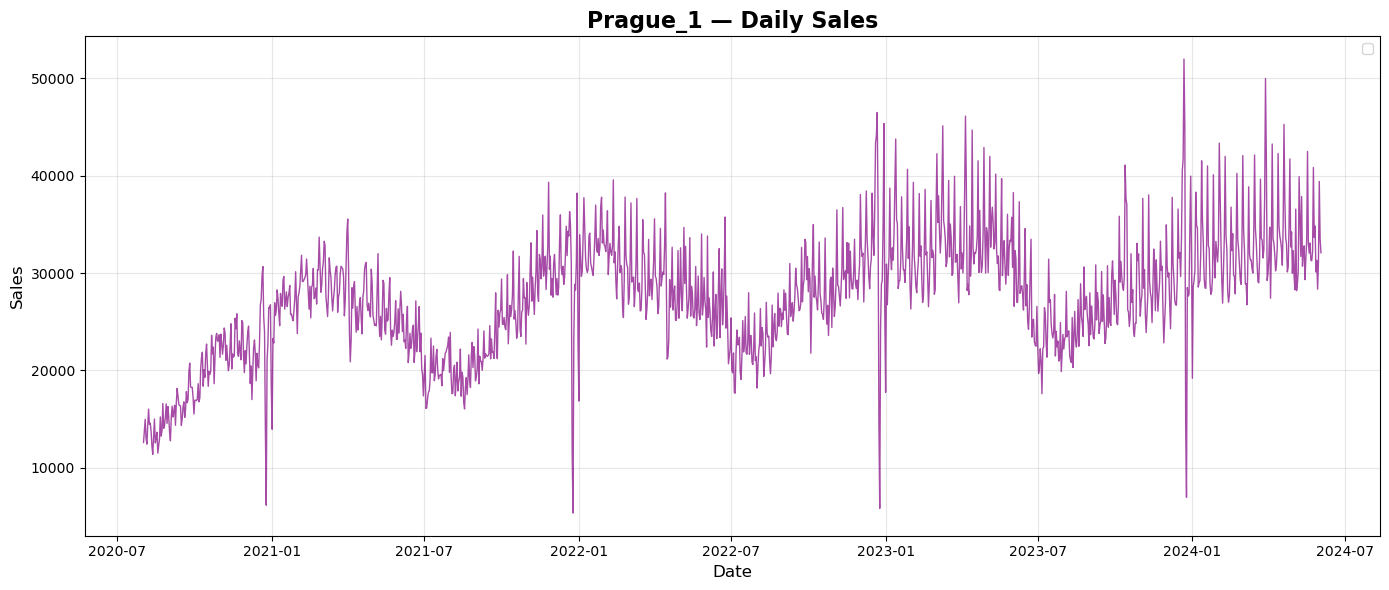

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


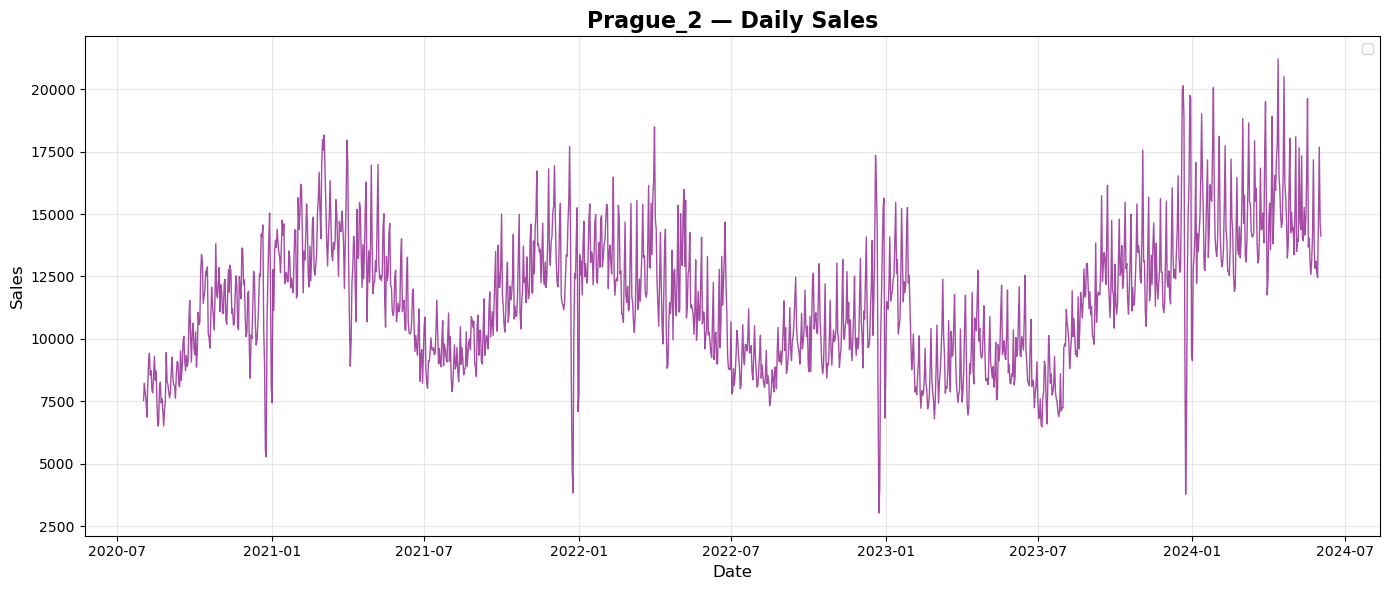

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


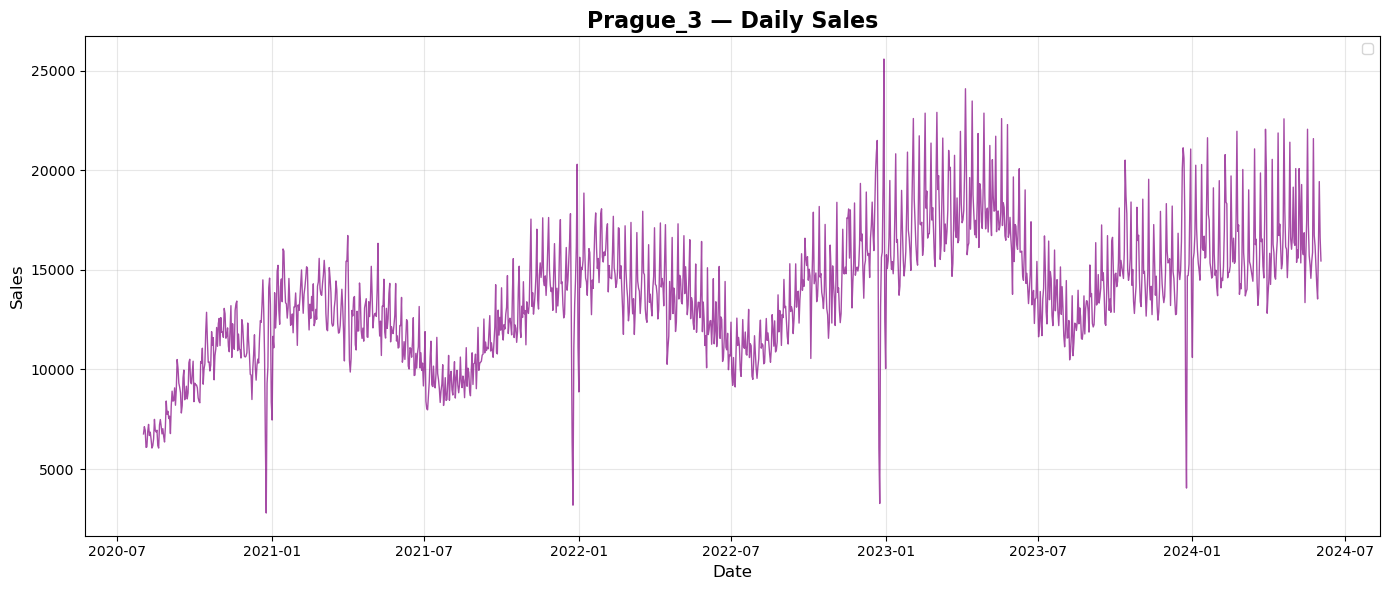

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


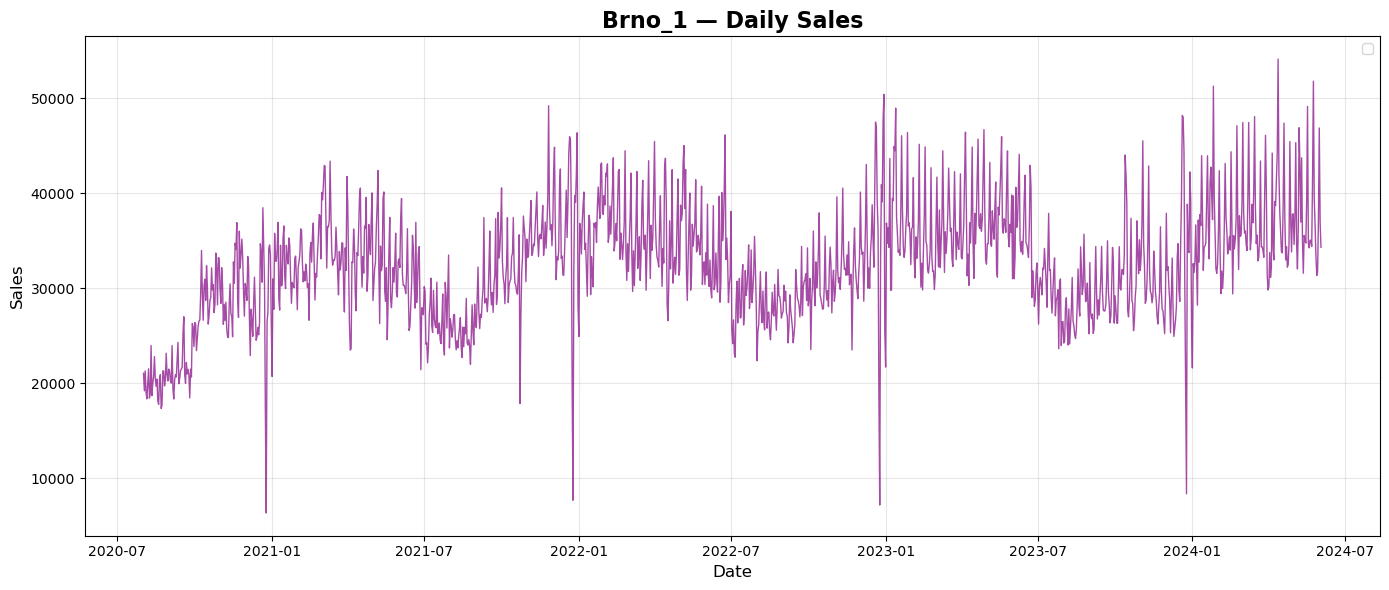

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


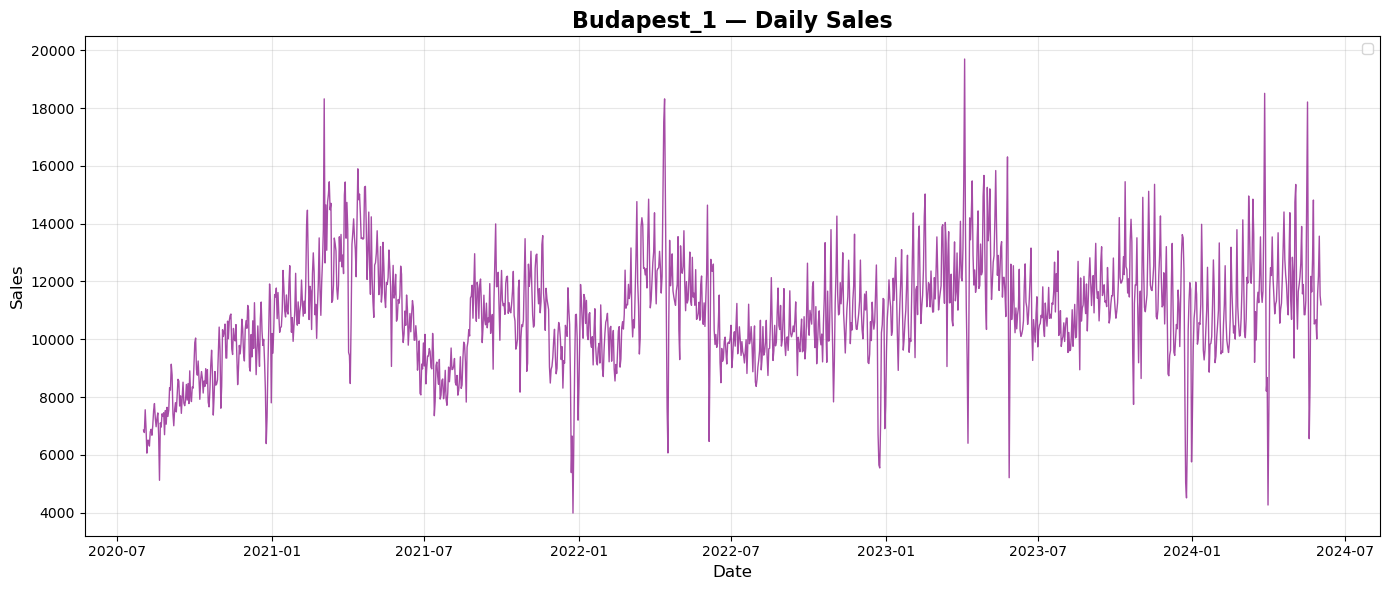

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


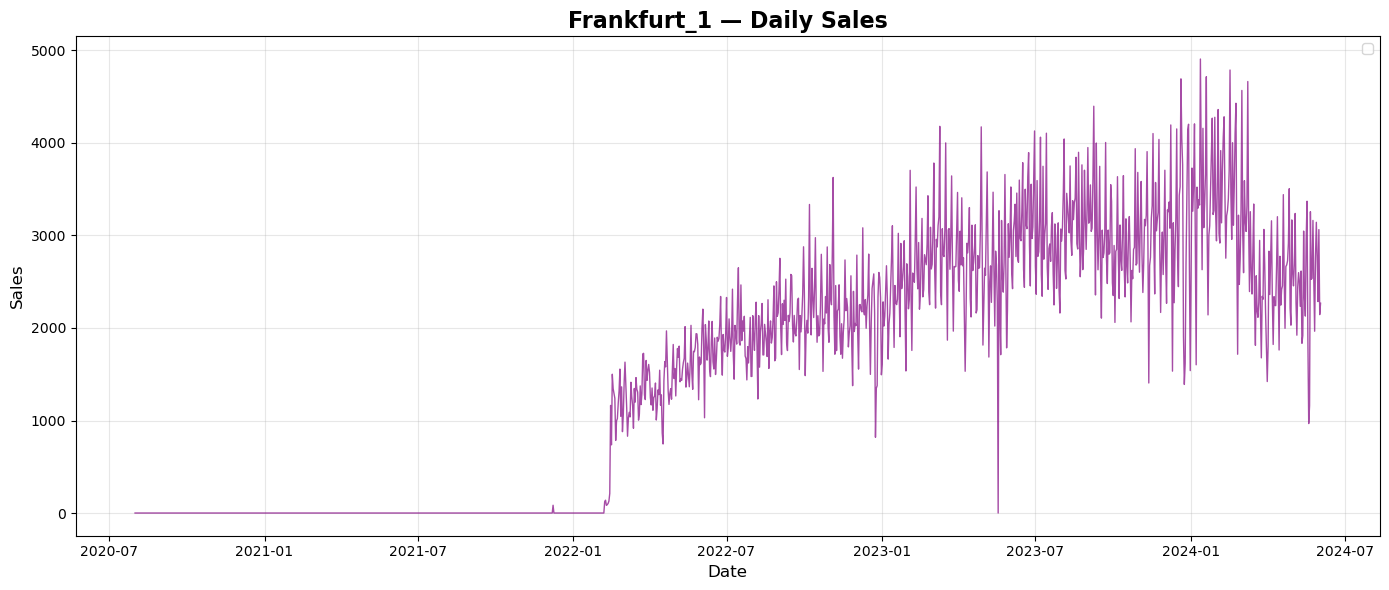

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


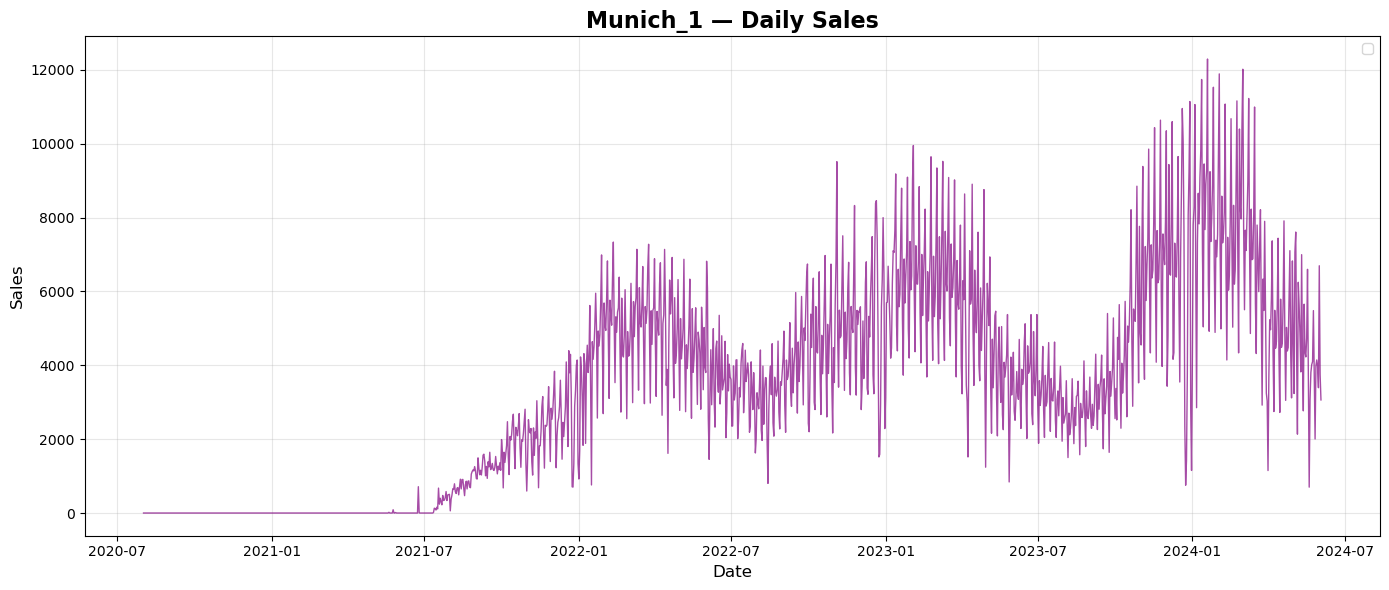

In [24]:
# | echo: false
# Group by date and warehouse, sum sales, reset index right away
data_train = data[data["is_test"] == 0].copy()

# Group by date and warehouse
ds = (
    data_train
    .groupby(["date", "warehouse"])["sales"]
    .sum()
    .reset_index()
    .sort_values(["warehouse", "date"])
)

ds["date"] = pd.to_datetime(ds["date"])

warehouses = ["Prague_1", "Prague_2", "Prague_3", "Brno_1",
              "Budapest_1", "Frankfurt_1", "Munich_1"]


ds["date"] = pd.to_datetime(ds["date"])

# Plot each warehouse
for wh in warehouses:
    df_wh = ds[ds["warehouse"] == wh]
    if df_wh.empty:
        print(f"No data for {wh}")
        continue

    plt.figure(figsize=(14, 6))
    plt.plot(df_wh["date"], df_wh["sales"],
             linewidth=1.0, color="purple", alpha=0.7)
    plt.title(f"{wh} — Daily Sales", fontsize=16, weight="bold")
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Sales", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Prague and Brno are both in Czech Republic. Summary sales show simmilar repeated pattern of sales during every year with tendency to grow every year.
Budapest is the capital of Hungary. Summary sales plot shows again repeated pattern of sales over years, but a bit different than plots from Czech Republic. There seems to be no tendency of growth over the years.
City of Munich is in Germany. Plot of summary daily sales shows again repeated pattern of sales over every year with a tendency to grow each year.
City of Frankfurt is in Germany, too. Plot of summary daily sales does not seems to copy the pattern of Munich but there is a tendency to grow each year.

#### Average sales during weekdays

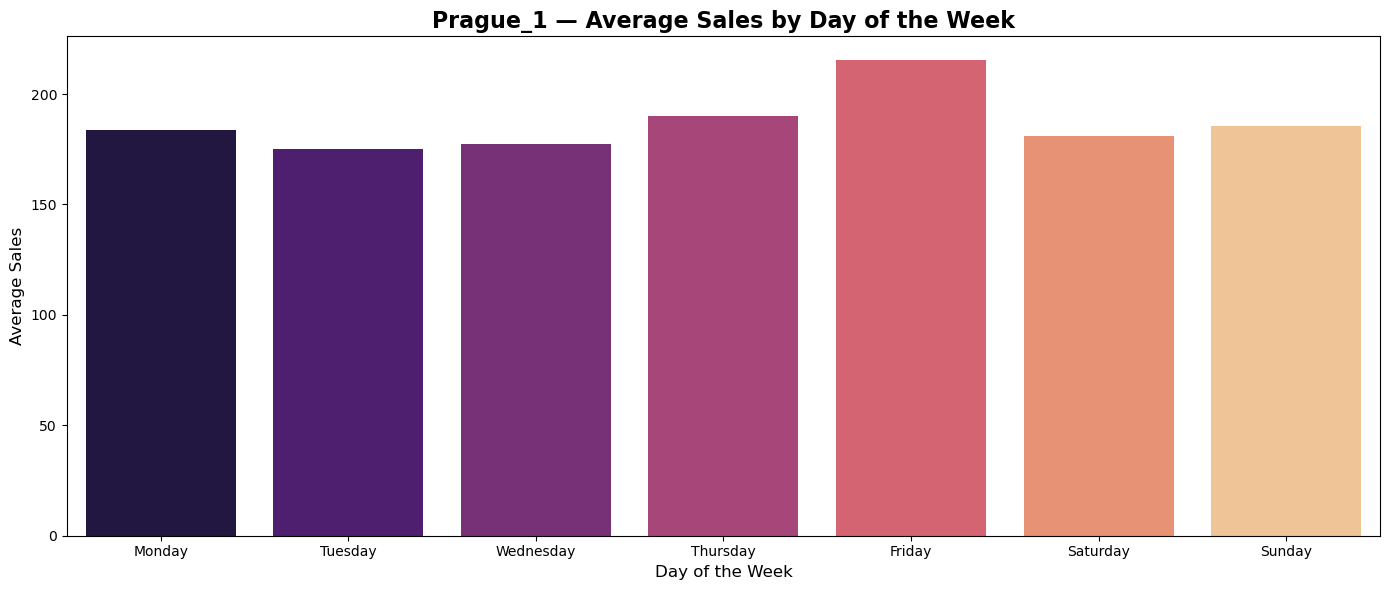

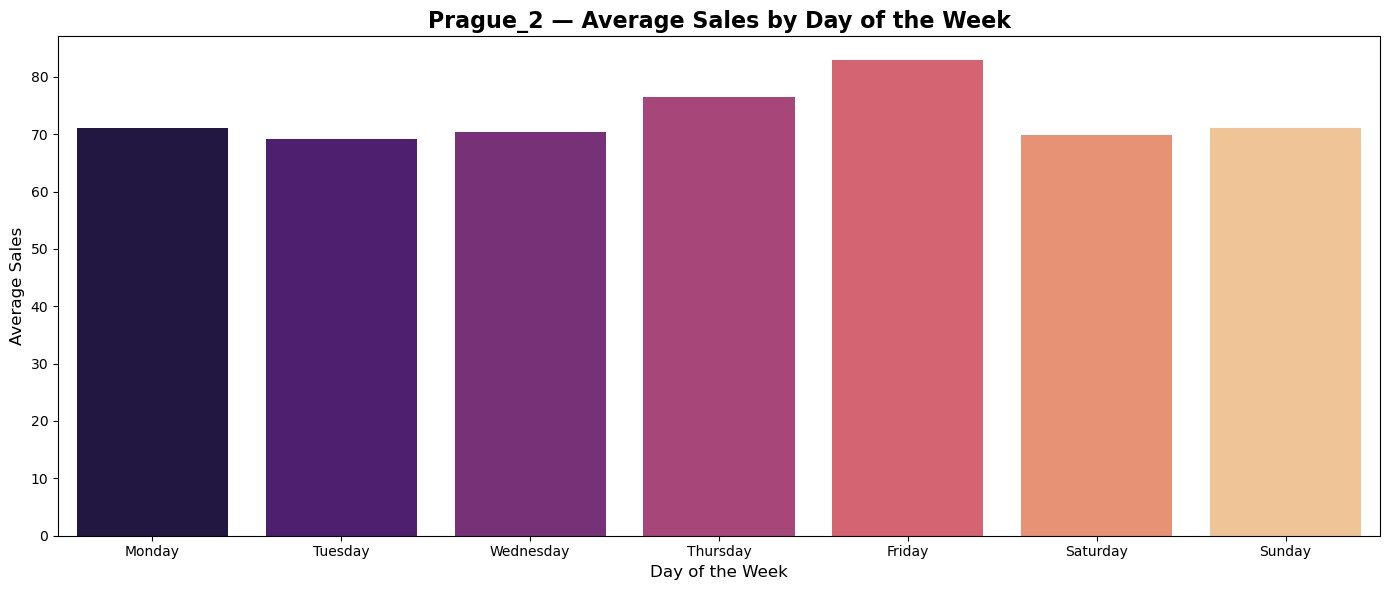

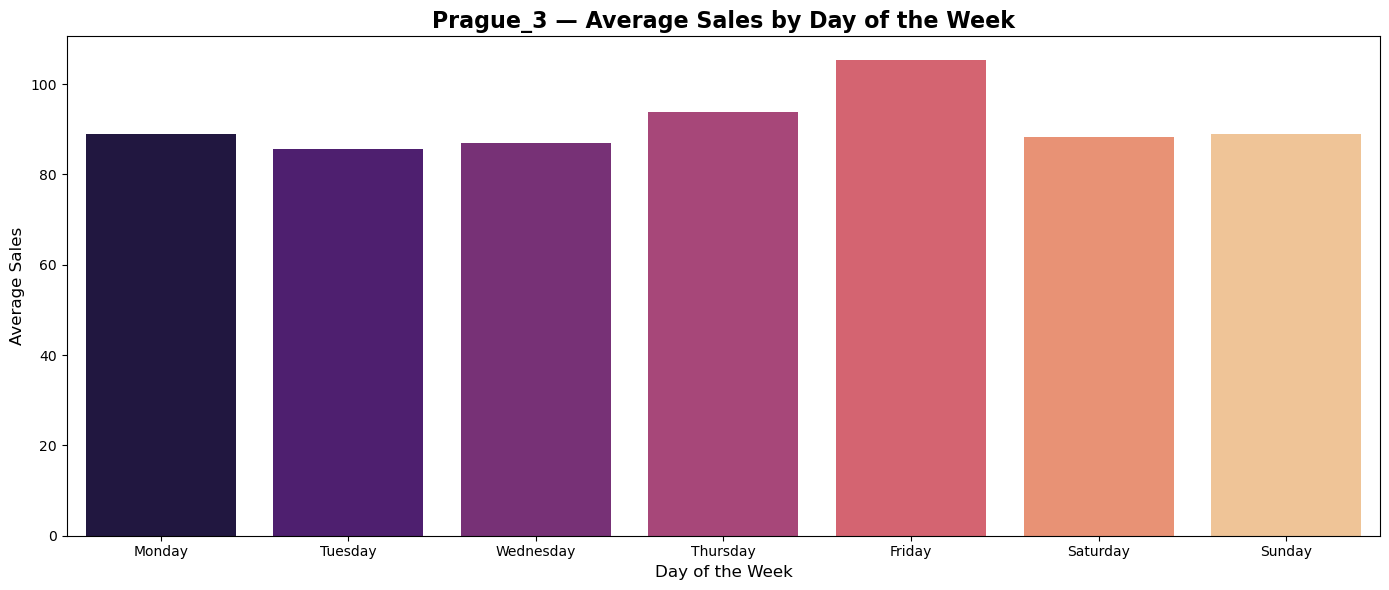

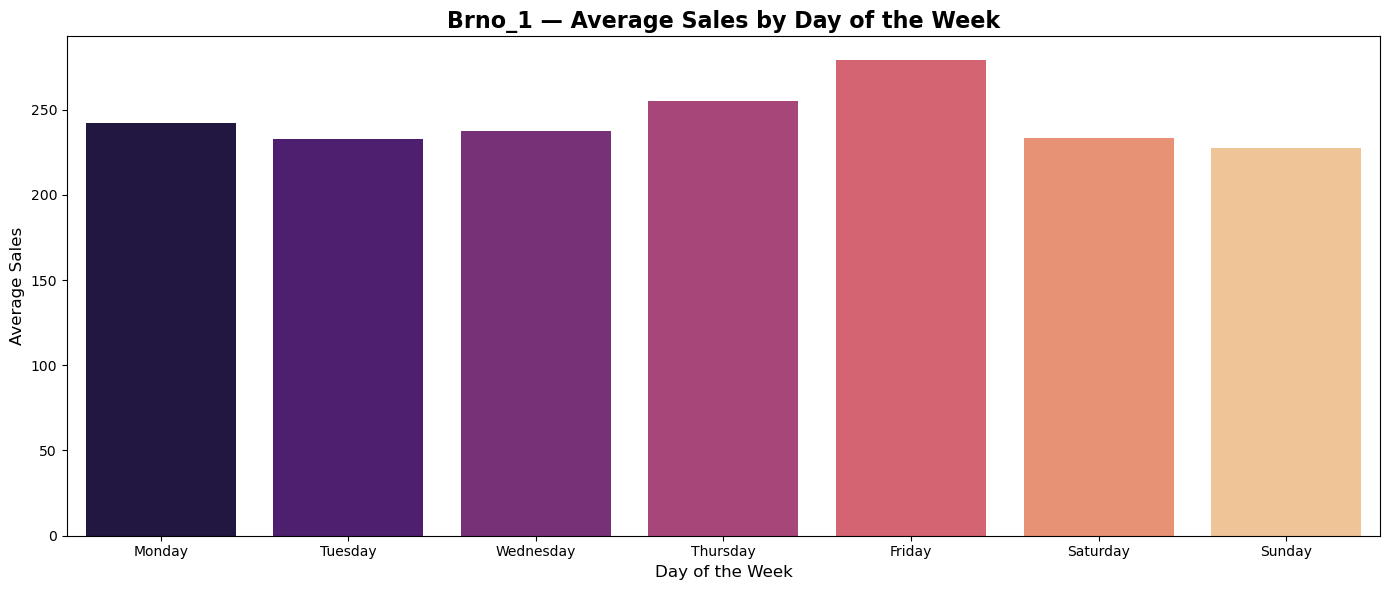

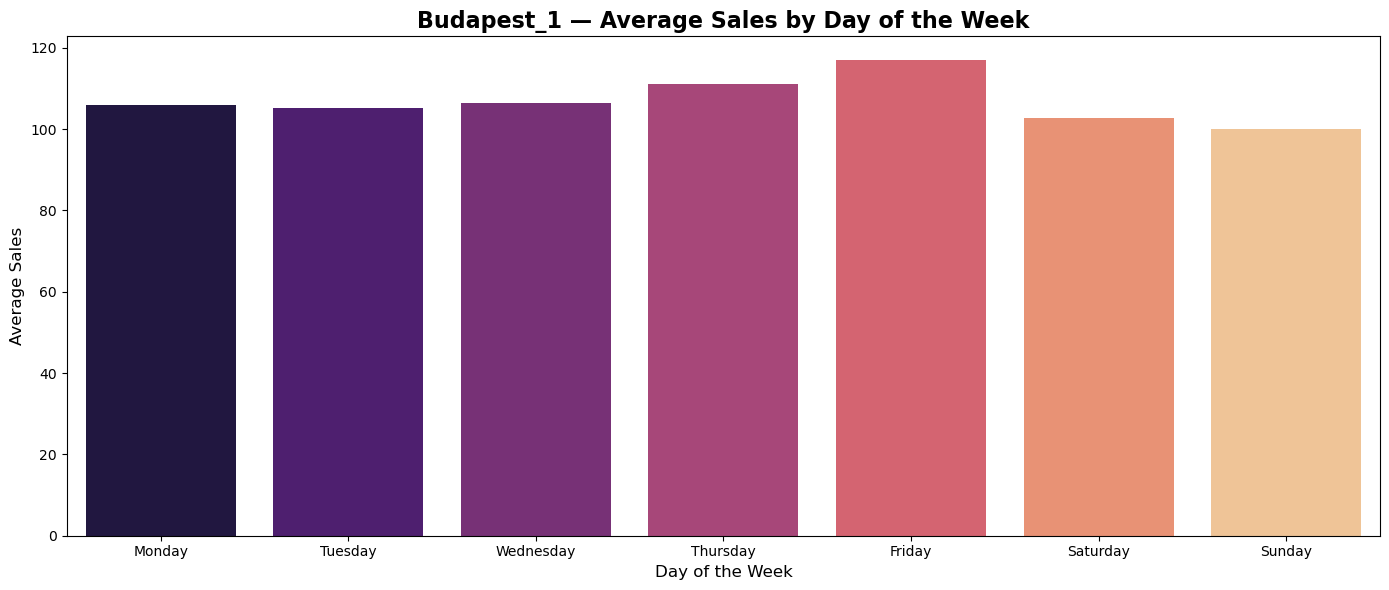

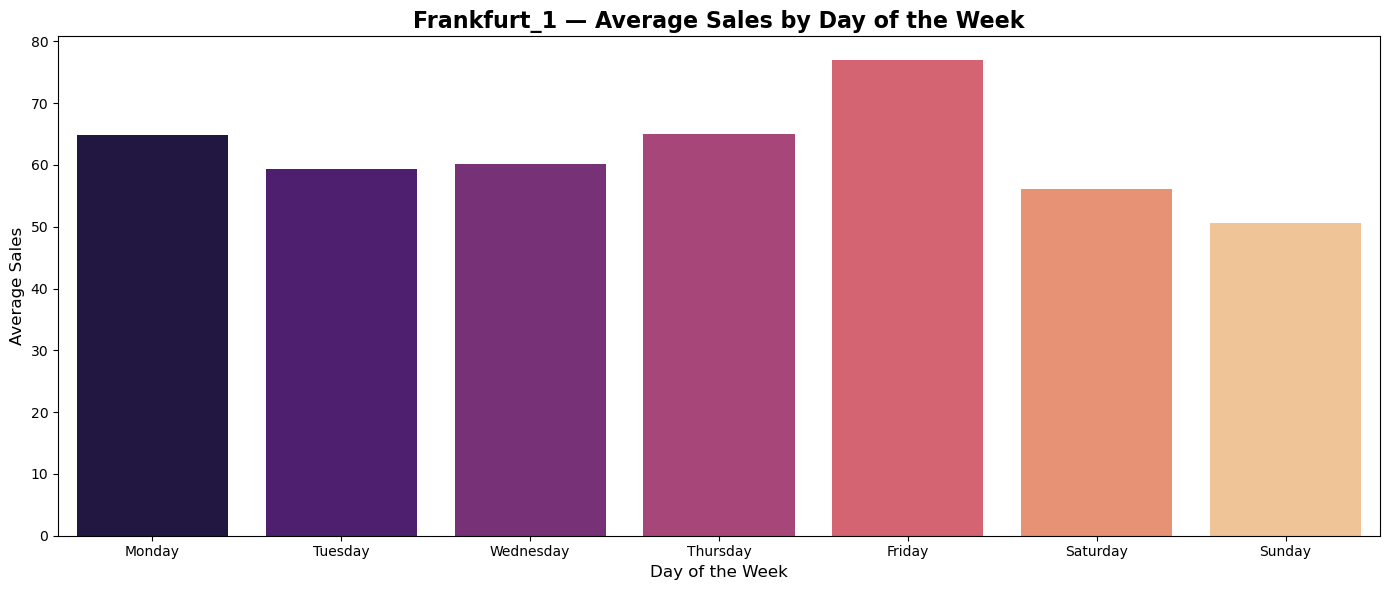

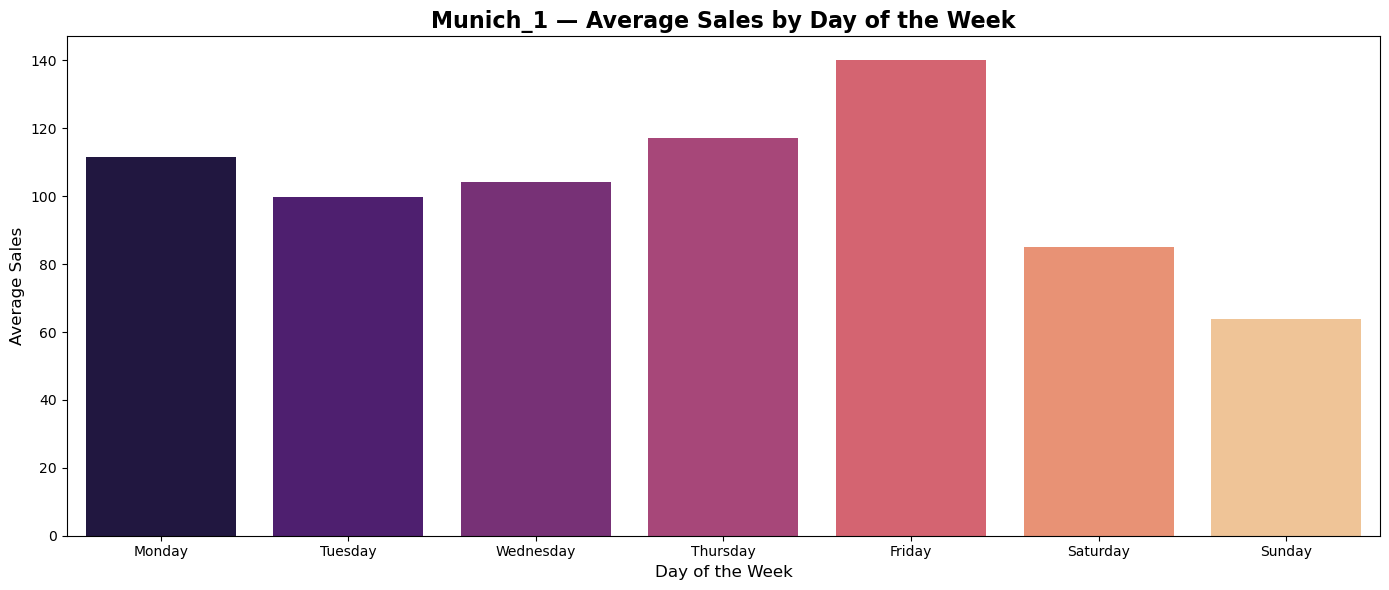

In [25]:
# | echo: false
# creating day names for plotting
data["day_name"] = data["date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
data["day_name"] = pd.Categorical(data["day_name"], categories=day_order, ordered=True)

# average sales by warehouse and weekday
week_average = (data
    .groupby(["warehouse", "day_name"], as_index=False)
    .agg(sales=("sales", "mean"))
)

for wh in warehouses:
    df_wh = week_average[week_average["warehouse"] == wh]
    if df_wh.empty:
        print(f"No data for {wh}")
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(
        x="day_name", y="sales", data=df_wh,
        order=day_order, ax=ax, palette="magma"
    )

    ax.set_title(f"{wh} — Average Sales by Day of the Week", fontsize=16, weight="bold")
    ax.set_xlabel("Day of the Week", fontsize=12)
    ax.set_ylabel("Average Sales", fontsize=12)
    plt.tight_layout()
    plt.show()

Plots of average sales during weekdays shows tendency of custumers in all countries to do shopping on Thurdays and Fridays.

#### Average monthly sales

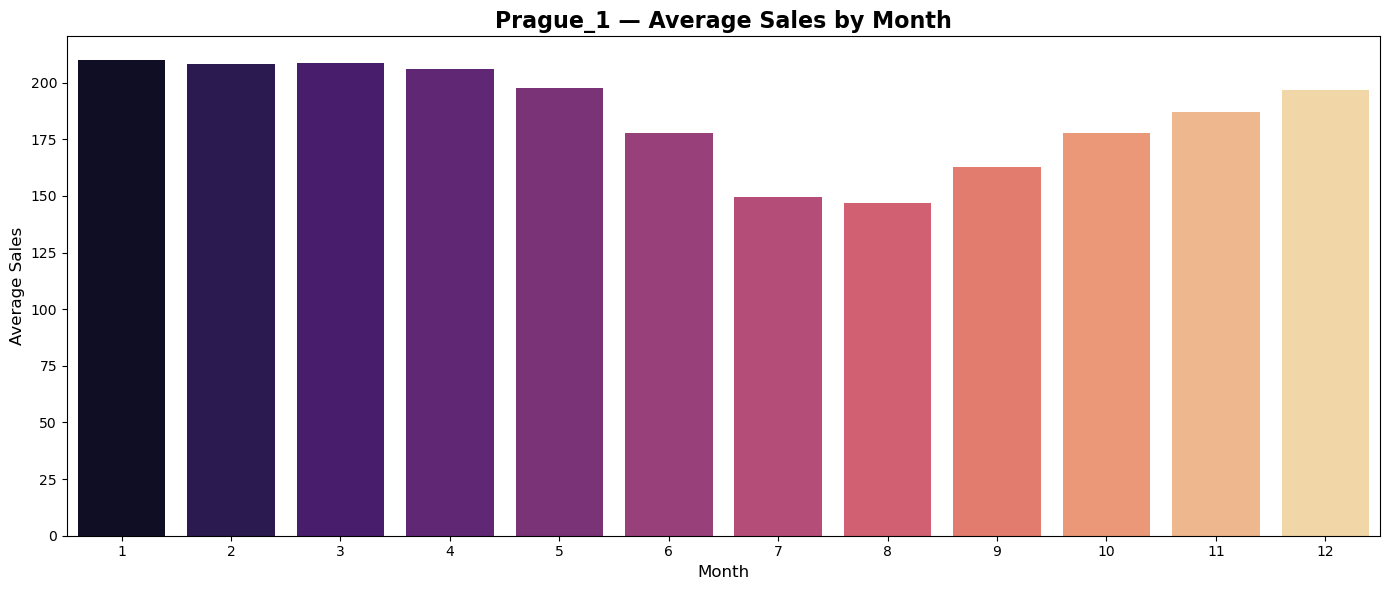

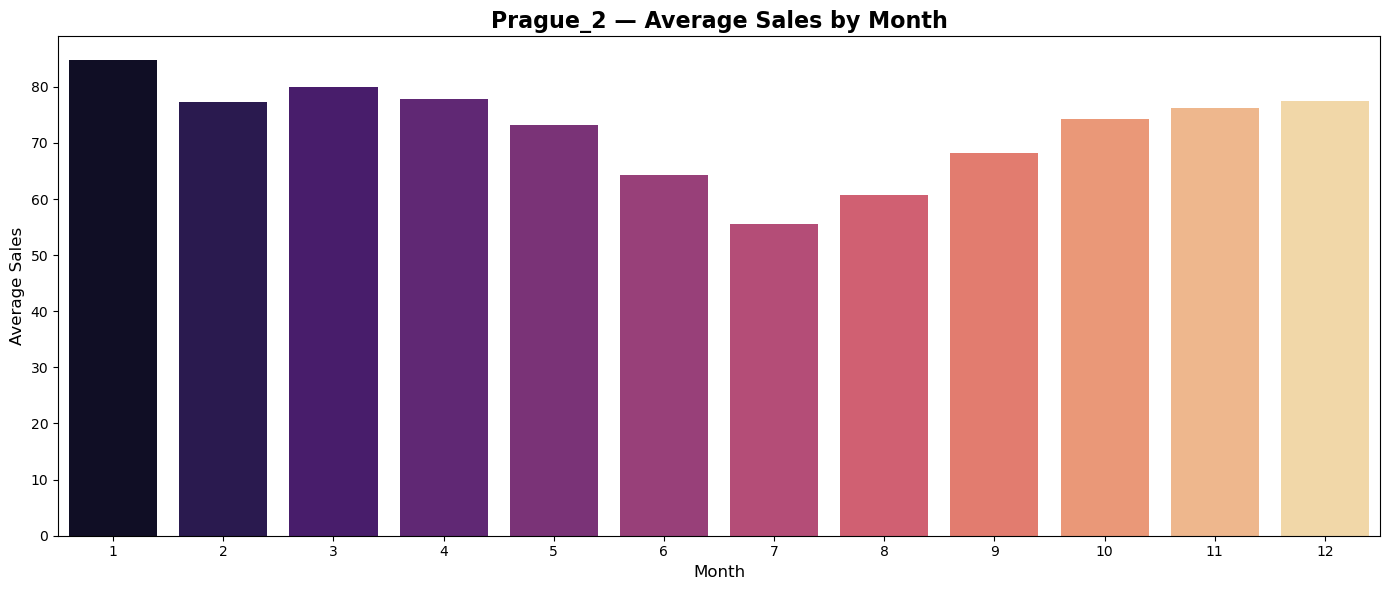

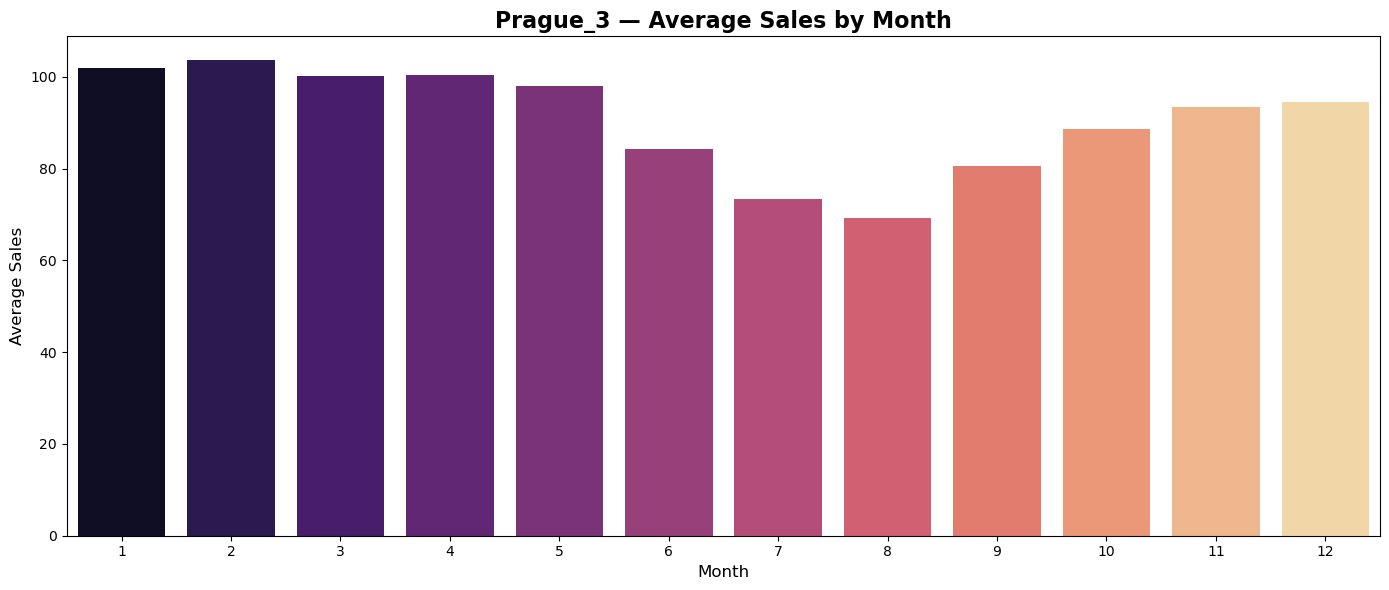

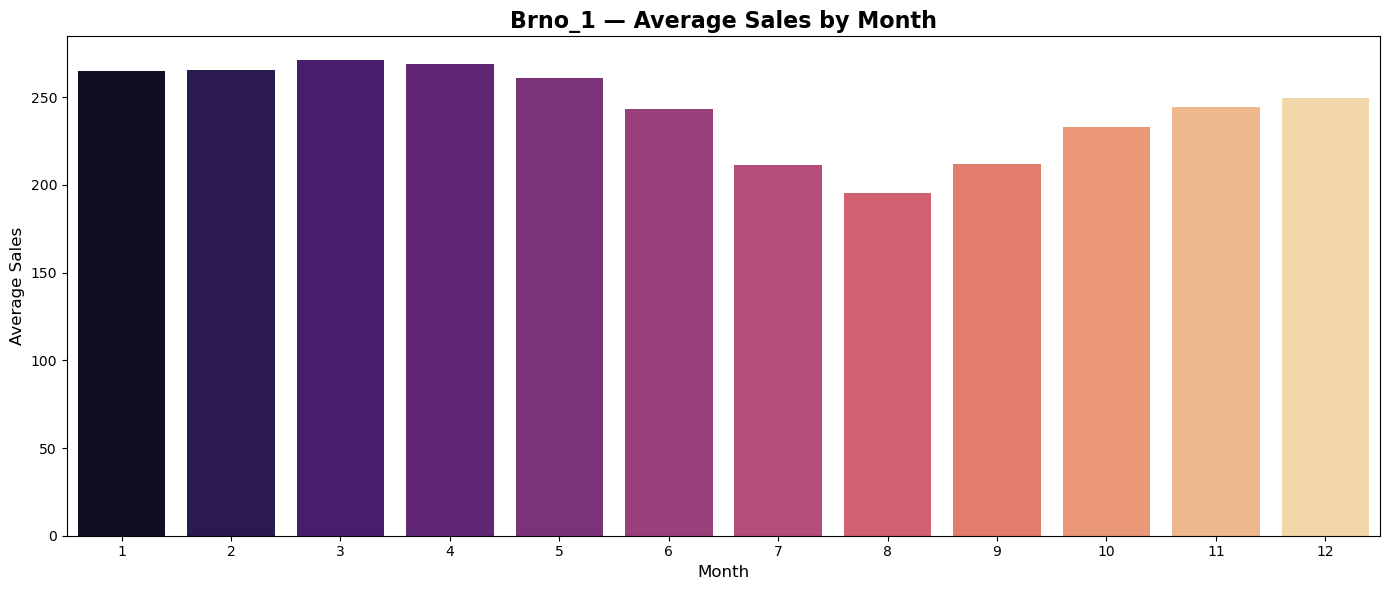

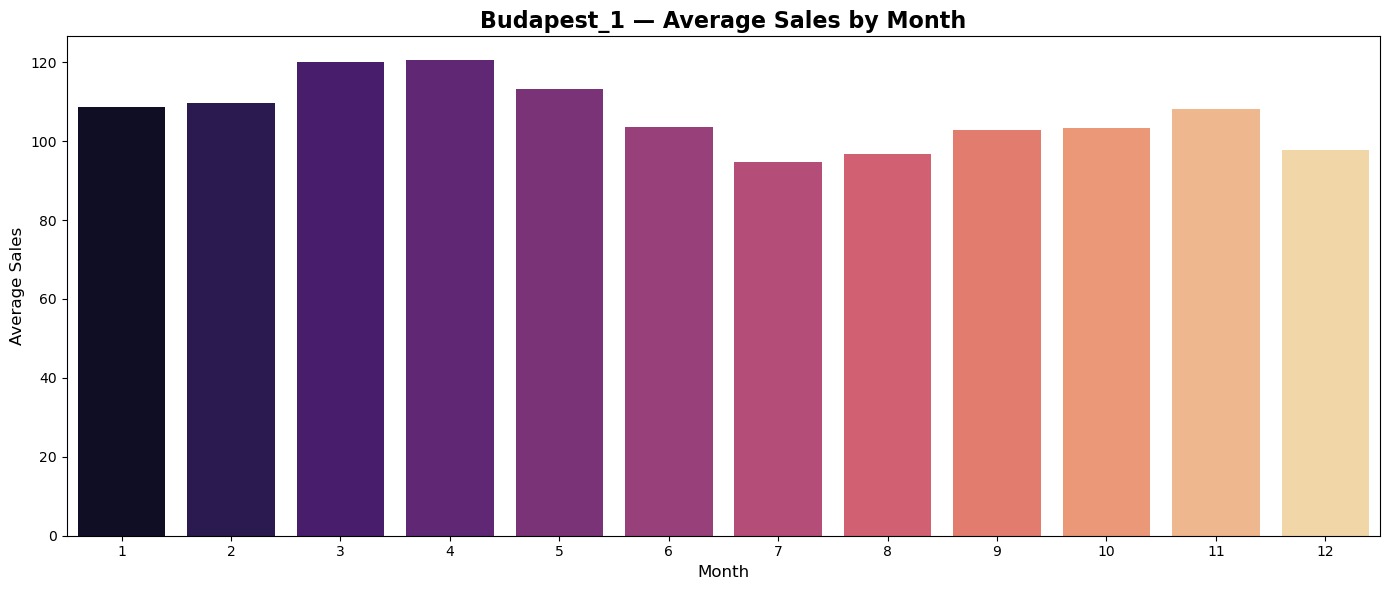

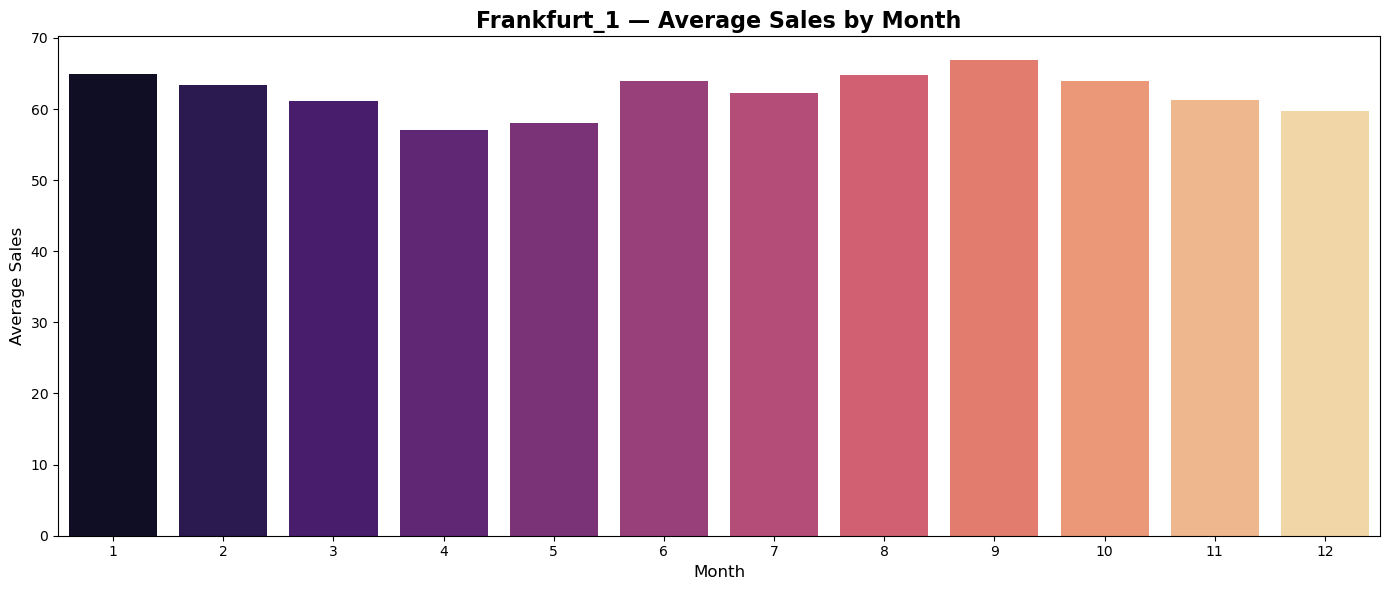

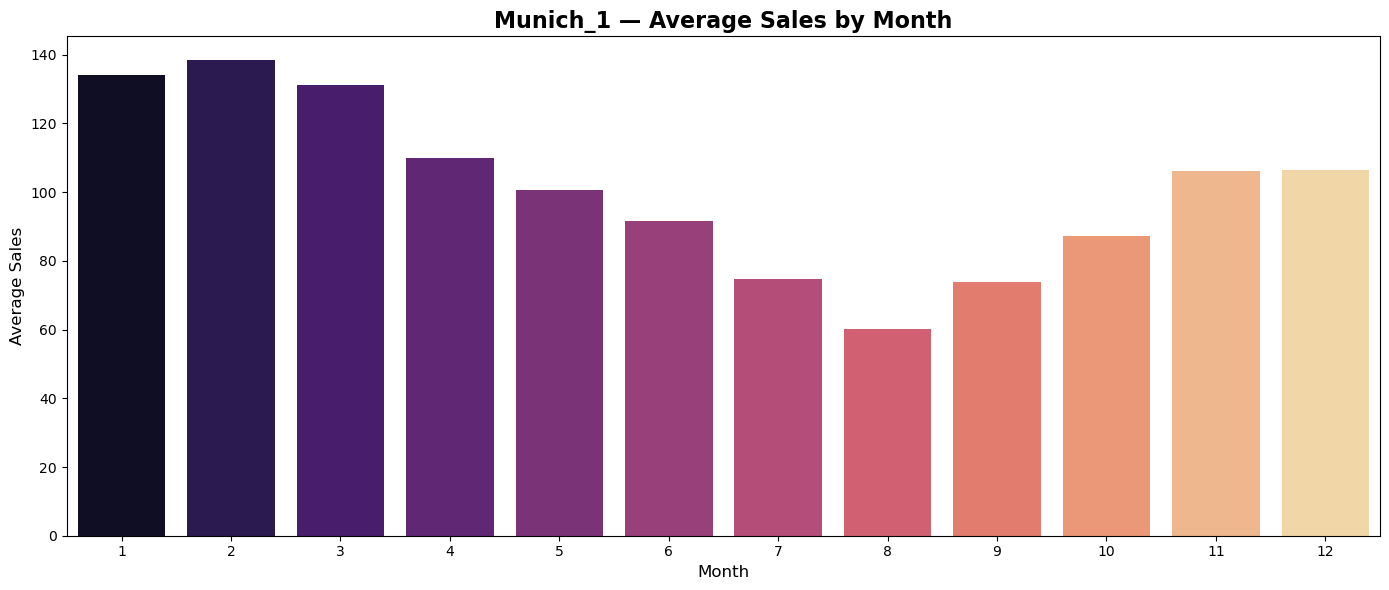

In [26]:
# | echo: false
monthly_average = (data
    .groupby(["warehouse", "month"], as_index=False)
    .agg(sales=("sales", "mean"))
)

for wh in warehouses:
    df_wh = monthly_average[monthly_average["warehouse"] == wh]
    if df_wh.empty:
        print(f"No data for {wh}")
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(x="month", y="sales", data=df_wh, ax=ax, palette="magma", order=list(range(1, 13)))

    ax.set_title(f"{wh} — Average Sales by Month", fontsize=16, weight="bold")
    ax.set_xlabel("Month", fontsize=12)
    ax.set_ylabel("Average Sales", fontsize=12)
    plt.tight_layout()
    plt.show()

Plots of average monthly sales seems to reflect regionally differences in shopping habits of customers.

#### Average sales during holidays and common days

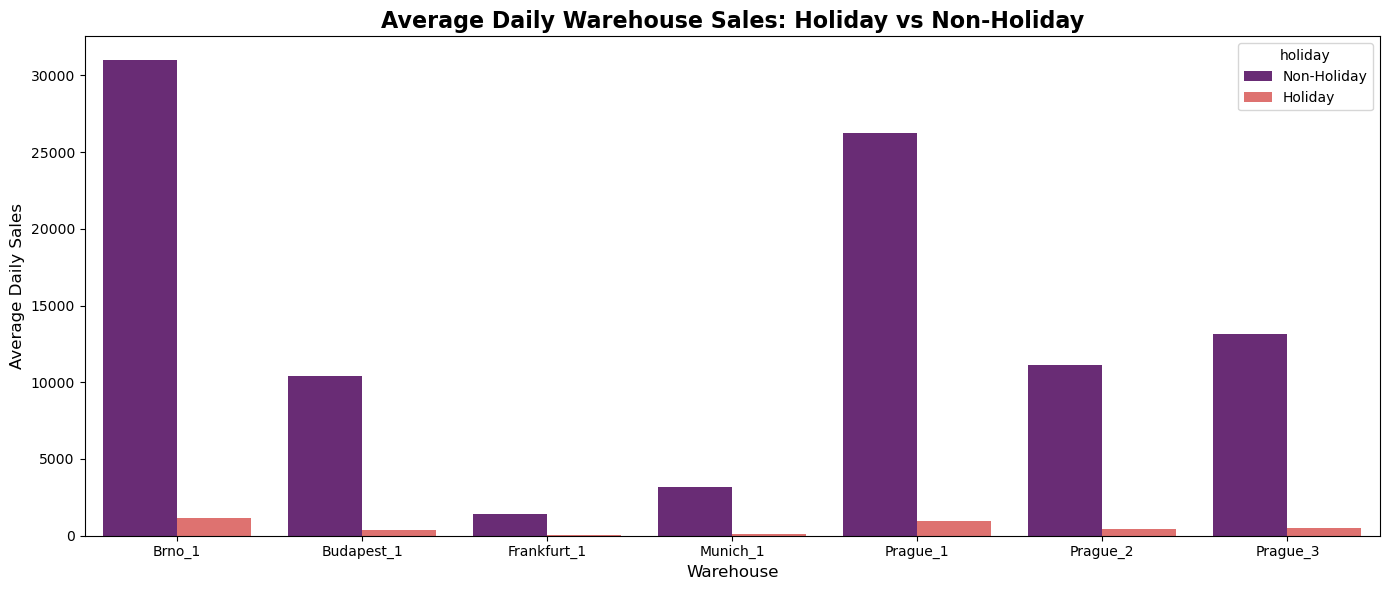

In [27]:
# | echo: false
# daily totals per warehouse
daily_wh = (data
    .groupby(["date", "warehouse", "holiday"])["sales"]
    .sum()
    .reset_index()
)

# average daily totals by holiday vs non-holiday
avg_holiday_sales = (daily_wh
    .groupby(["warehouse", "holiday"])["sales"]
    .mean()
    .reset_index()
)

# legend labels
avg_holiday_sales["holiday"] = avg_holiday_sales["holiday"].map({0: "Non-Holiday", 1: "Holiday"})

# plot
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    x="warehouse", y="sales",
    hue="holiday",
    data=avg_holiday_sales,
    palette="magma",
    ax=ax
)

ax.set_title("Average Daily Warehouse Sales: Holiday vs Non-Holiday", fontsize=16, weight="bold")
ax.set_xlabel("Warehouse", fontsize=12)
ax.set_ylabel("Average Daily Sales", fontsize=12)
plt.tight_layout()
plt.show()

## Prediction

#### Data preparation
To improve model performance, several time-series features will be created, including lagged values, rolling means, and momentum indicators, which will help capture temporal dependencies and short-term trends in the data. Lag features use past observations as predictors, rolling means summarize recent behaviour through moving averages, and momentum measures quantify the recent change in a variable.

In [28]:
# feature engineering
lags = [1, 2, 3, 7, 14, 21, 28, 35, 42, 56]

for lag in lags:
    data[f"lag_{lag}"] = (
        data.groupby("unique_id")["sales"]
        .shift(lag)
    )


lags = [1, 7, 14, 28]

for lag in lags:
    data[f"orders_lag_{lag}"] = (
        data.groupby("warehouse")["total_orders"]
        .shift(lag)
    )


# rolling 
windows = [7, 14, 28]

for w in windows:
    data[f"roll_mean_{w}"] = (
        data.groupby("unique_id")["sales"]
        .shift(1)
        .rolling(w)
        .mean()
        )
    


# simple momentum signals 
data["trend_ratio"] = data["roll_mean_7"] / (data["roll_mean_28"] + 1e-6)
data["momentum_7"] = data["lag_1"] - data["lag_7"]


# warehouse daily total trend
data["warehouse_roll7"] = (
    data.groupby(["warehouse", "date"])["sales"]
    .transform("sum")
    .groupby(data["warehouse"])
    .transform(lambda x: x.shift(1).rolling(7).mean())
)


data["product_roll7"] = (
    data.groupby(["product_unique_id", "date"])["sales"]
    .transform("sum")
    .groupby(data["product_unique_id"])
    .transform(lambda x: x.shift(1).rolling(7).mean())
    )



data["orders_roll7"] = (
    data.groupby("warehouse")["total_orders"]
    .shift(1)
    .rolling(7)
    .mean()
)


# dropping redundant columns
data = data.drop(columns=['holiday_name', 'name', 'day' ])

cat_cols = [
    "warehouse",
    "day_of_week",
    "L1_category_name_en",
    "L2_category_name_en",
    "L3_category_name_en",
    "L4_category_name_en",
    "product_unique_id"
]

for col in cat_cols:
    data[col] = data[col].astype("category")



### Model
LightGBM is a machine learning algorithm that predicts outcomes by combining many simple decision trees. Each tree learns from the errors of the previous ones and gradually improves the prediction, allowing the model to capture complex patterns in the data and achieve high predictive accuracy.

In [29]:
# train
train_final = data[data["is_test"] == 0].copy()

# drop rows with missing sales / missing lag history 
train_final = train_final.dropna().copy()

y = train_final["sales"].values.ravel()
X = train_final.drop(columns=["sales"]).copy()

# Time split on train
cutoff = train_final["date"].max() - pd.Timedelta(days=14)
train_mask = train_final["date"] < cutoff
valid_mask = train_final["date"] >= cutoff

X_train = X.loc[train_mask].copy()
X_valid = X.loc[valid_mask].copy()
y_train = y[train_mask.values]
y_valid = y[valid_mask.values]

# Weights 
train_weights = X_train["weight"].values
valid_weights = X_valid["weight"].values

# Drop non-features 
drop_cols = ["unique_id", "date", "is_test", "weight"]
X_train_model = X_train.drop(columns=drop_cols, errors="ignore")
X_valid_model = X_valid.drop(columns=drop_cols, errors="ignore")

model = LGBMRegressor(
    
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
    force_row_wise=True

)

model.fit(
    X_train_model, y_train,
    sample_weight=train_weights,
    eval_set=[(X_valid_model, y_valid)],
    eval_sample_weight=[valid_weights],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(400)]
)

pred = model.predict(X_valid_model)

wmae = np.sum(valid_weights * np.abs(y_valid - pred)) / np.sum(valid_weights)
mae = mean_absolute_error(y_valid, pred)

print("Validation WMAE:", wmae)
print("MAE:", mae)

[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
[LightGBM] [Info] Total Bins 8125
[LightGBM] [Info] Number of data points in the train set: 981146, number of used features: 46
[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
[LightGBM] [Info] Start training from score 80.861976
Training until validation scores don't improve for 400 rounds
Early stopping, best iteration is:
[3343]	valid_0's l1: 14.4715	valid_0's l2: 1304.26
[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples

The model is trained using all historical data except for the final 14 days. These last 14 days are held out as a validation set to evaluate how well the model predicts future sales. After training, the model generates predictions for this period, and the predicted values are compared with the actual observed sales to assess model performance.

In [30]:
# | echo: false
# prediction
pred = model.predict(X_valid_model)

wmae = np.sum(valid_weights * np.abs(y_valid - pred)) / np.sum(valid_weights)
print("Validation WMAE:", wmae)

[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
Validation WMAE: 14.4714968291173


The final training of the LightGBM model using the entire training dataset after the model parameters have already been validated.

In [31]:
X_full = train_final.drop(columns=["sales", "unique_id", "date", "is_test", "weight"], errors="ignore")
y_full = train_final["sales"].values
weights_full = train_final["weight"].values

final_model = LGBMRegressor(
    n_estimators=model.best_iteration_,
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
    force_row_wise=True
)

final_model.fit(X_full, y_full, sample_weight=weights_full)

[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
[LightGBM] [Info] Total Bins 8115
[LightGBM] [Info] Number of data points in the train set: 993369, number of used features: 46
[LightGBM] [Info] Start training from score 80.844171


LGBMRegressor(colsample_bytree=0.8, force_row_wise=True, learning_rate=0.03,
              min_data_in_leaf=150, n_estimators=3343, num_leaves=63,
              random_state=42, reg_lambda=2.0, subsample=0.8)

In [32]:
# | echo: false
# prediction and evaluation
pred_full = final_model.predict(X_full)

mae_full = mean_absolute_error(y_full, pred_full)
print("Train MAE:", mae_full)
wmae_full = np.sum(weights_full * np.abs(y_full - pred_full)) / np.sum(weights_full)

print("Train WMAE:", wmae_full)

[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150
Train MAE: 16.073860052291398
Train WMAE: 12.07818805959296


In [33]:
avg_sales = data["sales"].mean()
print("Average sales:", avg_sales)

Average sales: 135.09114999103528


Relative error:

12.08/135.09≈0.0894

Accuracy:

1
−
0.0894
≈
0.9106

Result

≈ 91.1% training accuracy

### Final Solution:

In [34]:
test_final = data[data["is_test"] == 1].copy()

X_test = test_final.drop(columns=["sales", "unique_id", "date", "is_test", "weight"], errors="ignore")

pred_test = final_model.predict(X_test)
pred_test = np.clip(pred_test, 0, None)

solution_df["sales_hat"] = pred_test

solution_df.to_csv("../rohlik_project/csv/solution.csv", index=False)

solution_df.head()

[LightGBM] [Warning] min_data_in_leaf is set=150, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=150


,id,sales_hat
0,Brno_1_1226_2024-06-03,10.486372
1,Brno_1_1226_2024-06-11,8.936784
2,Brno_1_1226_2024-06-13,9.241525
3,Brno_1_1226_2024-06-15,10.004795
4,Brno_1_1226_2024-06-09,12.988256


## Conclusion

Overall, the project demonstrates that machine learning methods such as LightGBM can effectively model retail demand when combined with appropriate feature engineering and time-based validation. Future improvements could include additional external features, more advanced time-series modelling techniques, or ensemble approaches to further enhance forecasting accuracy.

***
### End